### Imports + Chargement

In [1]:
import joblib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import mlflow.lightgbm
import mlflow.xgboost

from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    make_scorer
)
from sklearn.model_selection import StratifiedKFold, cross_validate


from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE


In [2]:
# Chargement des jeux préparés
X_train = joblib.load("../data/X_train.pkl")
X_test = joblib.load("../data/X_test.pkl")
y_train = joblib.load("../data/y_train.pkl")
y_test = joblib.load("../data/y_test.pkl")

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (246008, 304)
X_test  : (61503, 304)
y_train : (246008,)
y_test  : (61503,)


### Configuration MLflow

In [3]:
PROJECT_ROOT = Path.cwd().parent

# Base SQLite à la racine
db_path = PROJECT_ROOT / "mlflow.db"

# Dossier artefacts MLflow à la racine
mlruns_path = PROJECT_ROOT / "mlruns"
mlruns_path.mkdir(exist_ok=True)

# Connexion MLflow
mlflow.set_tracking_uri(f"sqlite:///{db_path.as_posix()}")

# Création ou sélection de l'expérience
experiment_name = "Credit Scoring"

if mlflow.get_experiment_by_name(experiment_name) is None:
    mlflow.create_experiment(
        experiment_name,
        artifact_location=mlruns_path.resolve().as_uri()
    )

mlflow.set_experiment(experiment_name)

2026/04/25 04:11:58 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/25 04:11:58 INFO mlflow.store.db.utils: Updating database tables


<Experiment: artifact_location='file:///C:/Users/ocean/Documents/Credit-Scoring/mlruns', creation_time=1777083120982, experiment_id='1', last_update_time=1777083120982, lifecycle_stage='active', name='Credit Scoring', tags={}, workspace='default'>

### Fonctions d'évaluation

In [4]:
def business_cost(y_true, y_pred, fn_cost=10, fp_cost=1):
    """
    Coût métier du scoring crédit :

    FN (faux négatif) :
    client prédit solvable alors qu'il fera défaut
    -> coût élevé

    FP (faux positif) :
    client refusé alors qu'il était solvable
    -> coût plus faible
    """

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return fn * fn_cost + fp * fp_cost

def evaluate_model_and_log(model, X_test, y_test, model_name):
    """
    Évalue un modèle sur le jeu de test et enregistre les résultats dans MLflow.

    La fonction calcule les métriques principales, génère une matrice de confusion,
    sauvegarde le graphique dans reports/figures/modeling, puis l'ajoute comme artefact MLflow.
    """

    # Prédictions de classe et probabilités de défaut
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Calcul des métriques de performance
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "business_cost": business_cost(y_test, y_pred)
    }

    # Enregistrement des métriques dans MLflow
    mlflow.log_metrics(metrics)

    # Création de la matrice de confusion
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matrice de confusion - {model_name}")
    plt.xlabel("Prédit")
    plt.ylabel("Réel")

    # Sauvegarde locale dans le dossier reports
    figures_dir = PROJECT_ROOT / "reports" / "figures" / "modeling"
    figures_dir.mkdir(parents=True, exist_ok=True)

    file_path = figures_dir / f"cm_{model_name.lower().replace(' ', '_')}.png"
    plt.savefig(file_path, bbox_inches="tight")

    # Enregistrement de la figure comme artefact MLflow
    mlflow.log_artifact(str(file_path), artifact_path="confusion_matrices")

    plt.show()
    plt.close()

    return metrics, y_pred, y_proba

### Fonction d'affichage

In [5]:
# Affichage lisible des métriques
def print_metrics(model_name, metrics):
    print(f"Résultats - {model_name}")
    for key, value in metrics.items():
        print(f"{key}: {value:.4f}")

In [6]:
# Liste pour stockage des résultats pour comparaison finale
results = []

In [7]:
# Tags standardisés pour rendre les runs MLflow comparables
model_families = {
    "DummyClassifier": "baseline",
    "LogisticRegression": "linear",
    "RandomForest": "bagging",
    "LightGBM": "boosting",
    "XGBoost": "boosting"
}

imbalance_strategies = {
    "DummyClassifier": "none",
    "LogisticRegression": "class_weight",
    "RandomForest": "class_weight",
    "LightGBM": "class_weight",
    "XGBoost": "scale_pos_weight"
}

### Première comparaison sur un split train/test

Cette première comparaison est réalisée sur un découpage classique train/test.  
Elle permet d’obtenir rapidement un benchmark initial des modèles, avant une évaluation plus robuste par validation croisée.
- train/test split classique
- pondération des classes (class_weight)
- seuil standard 0.5

#### DummyClassifier

Un modèle naïf est utilisé comme point de comparaison.
Il prédit systématiquement la classe majoritaire, ce qui permet de vérifier qu’un modèle plus avancé apporte une vraie valeur.

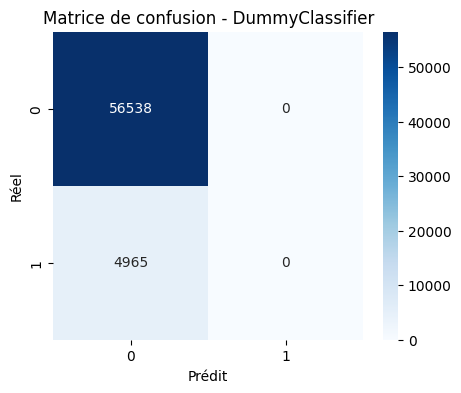

Résultats - DummyClassifier
accuracy: 0.9193
roc_auc: 0.5000
precision: 0.0000
recall: 0.0000
f1: 0.0000
business_cost: 49650.0000


In [8]:
# Baseline : DummyClassifier
with mlflow.start_run(run_name="baseline_dummy"):
    mlflow.set_tag("stage", "modeling")
    mlflow.set_tag("evaluation_type", "train_test")
    mlflow.set_tag("model_name", "DummyClassifier")
    mlflow.set_tag("model_family", "baseline")
    mlflow.set_tag("imbalance_strategy", "none")
    mlflow.set_tag("threshold", "0.50")
    mlflow.set_tag("description", "Baseline naïve prédisant la classe majoritaire")

    # DummyClassifier : modèle naïf qui prédit toujours la classe majoritaire
    dummy = DummyClassifier(strategy="most_frequent", random_state=42)
    dummy.fit(X_train, y_train)

    # Évaluation et Logging
    mlflow.log_param("strategy", "most_frequent")
    metrics, y_pred, y_proba = evaluate_model_and_log(dummy, X_test, y_test, "DummyClassifier")

    # Affichage console
    print_metrics("DummyClassifier", metrics)

    # Stockage pour comparaison finale
    results.append({"model": "DummyClassifier", **metrics})

#### Logistic Regression

La régression logistique constitue une baseline supervisée classique en scoring crédit.
Elle est simple, interprétable et adaptée à une première comparaison.

c:\Users\ocean\Documents\Credit-Scoring\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


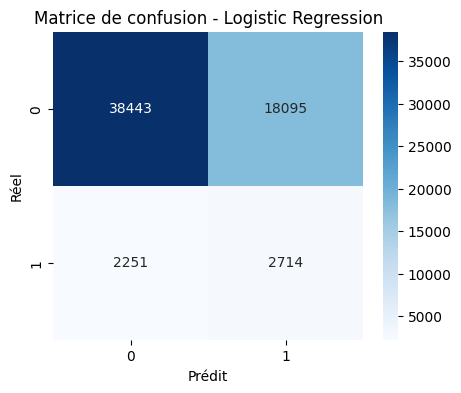

Résultats - LogisticRegression
accuracy: 0.6692
roc_auc: 0.6567
precision: 0.1304
recall: 0.5466
f1: 0.2106
business_cost: 40605.0000


In [9]:
with mlflow.start_run(run_name="logistic_regression"):
    mlflow.set_tag("stage", "modeling")
    mlflow.set_tag("evaluation_type", "train_test")
    mlflow.set_tag("model_name", "LogisticRegression")
    mlflow.set_tag("model_family", "linear")
    mlflow.set_tag("imbalance_strategy", "class_weight")
    mlflow.set_tag("threshold", "0.50")
    mlflow.set_tag("description", "Régression logistique avec pondération des classes")

    # Régression logistique : modèle linéaire 
    log_reg = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42)
    log_reg.fit(X_train, y_train)

    # Évaluation et Logging
    mlflow.log_params({"class_weight": "balanced", "max_iter": 2000})
    metrics, y_pred, y_proba = evaluate_model_and_log(log_reg, X_test, y_test, "Logistic Regression")

    # Affichage console
    print_metrics("LogisticRegression", metrics)

    # Stockage pour comparaison finale
    results.append({"model": "LogisticRegression", **metrics})

#### LightGBM

LightGBM est un modèle de boosting souvent très performant sur les données tabulaires.
Il permet de capturer des relations non linéaires et des interactions plus complexes entre variables.

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.150333 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 28717
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 294
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


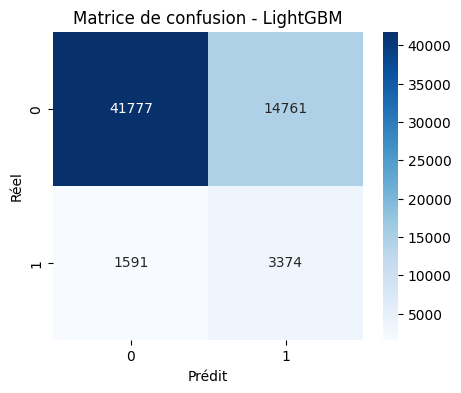

Résultats - LightGBM
accuracy: 0.7341
roc_auc: 0.7804
precision: 0.1860
recall: 0.6796
f1: 0.2921
business_cost: 30671.0000


In [10]:
with mlflow.start_run(run_name="lightgbm"):
    mlflow.set_tag("stage", "modeling")
    mlflow.set_tag("evaluation_type", "train_test")
    mlflow.set_tag("model_name", "LightGBM")
    mlflow.set_tag("model_family", "boosting")
    mlflow.set_tag("imbalance_strategy", "class_weight")
    mlflow.set_tag("threshold", "0.50")
    mlflow.set_tag("description", "LightGBM avec pondération des classes")

    # LightGBM : modèle de boosting adapté aux données tabulaires
    lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31, class_weight="balanced", random_state=42)
    lgbm.fit(X_train, y_train)

    # Évaluation et Logging (avec enregistrement dans le Registry)
    mlflow.log_params({"n_estimators": 300, "learning_rate": 0.05, "num_leaves": 31, "class_weight": "balanced"})
    metrics, y_pred, y_proba = evaluate_model_and_log(lgbm, X_test, y_test, "LightGBM")

    # Affichage console
    print_metrics("LightGBM", metrics)

    # Stockage pour comparaison finale
    results.append({"model": "LightGBM", **metrics})

#### Random Forest

Random Forest est un ensemble de nombreux arbres de décision entraînés sur des sous-échantillons aléatoires.
Il est robuste, simple à utiliser et permet de capturer des relations non linéaires, mais peut être moins performant que les méthodes de boosting sur les données tabulaires complexes.

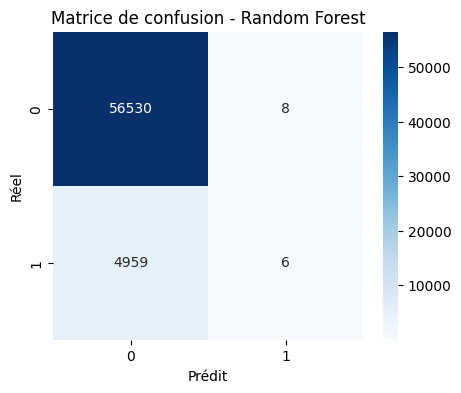

Résultats - RandomForest
accuracy: 0.9192
roc_auc: 0.7481
precision: 0.4286
recall: 0.0012
f1: 0.0024
business_cost: 49598.0000


In [11]:
with mlflow.start_run(run_name="random_forest"):
    mlflow.set_tag("stage", "modeling")
    mlflow.set_tag("evaluation_type", "train_test")
    mlflow.set_tag("model_name", "RandomForest")
    mlflow.set_tag("model_family", "bagging")
    mlflow.set_tag("imbalance_strategy", "class_weight")
    mlflow.set_tag("threshold", "0.50")
    mlflow.set_tag("description", "Random Forest avec pondération des classes")

    # Random Forest : modèle d'ensemble basé sur plusieurs arbres
    rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    # Évaluation et Logging
    mlflow.log_params({"n_estimators": 200, "class_weight": "balanced"})
    metrics, y_pred, y_proba = evaluate_model_and_log(rf, X_test, y_test, "Random Forest")

    # Affichage
    print_metrics("RandomForest", metrics)

    # Stockage des résultats
    results.append({"model": "RandomForest", **metrics})

#### XGBoost

XGBoost est un modèle de gradient boosting qui construit successivement des arbres corrigeant les erreurs des précédents, ce qui permet d’obtenir d’excellentes performances prédictives.

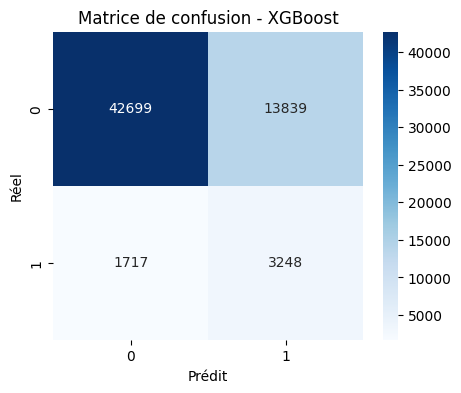

Résultats - XGBoost
accuracy: 0.7471
roc_auc: 0.7775
precision: 0.1901
recall: 0.6542
f1: 0.2946
business_cost: 31009.0000


In [12]:
with mlflow.start_run(run_name="xgboost"):
    mlflow.set_tag("stage", "modeling")
    mlflow.set_tag("evaluation_type", "train_test")
    mlflow.set_tag("model_name", "XGBoost")
    mlflow.set_tag("model_family", "boosting")
    mlflow.set_tag("imbalance_strategy", "scale_pos_weight")
    mlflow.set_tag("threshold", "0.50")
    mlflow.set_tag("description", "XGBoost avec scale_pos_weight pour gérer le déséquilibre")

    # Ratio pour compenser le déséquilibre
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    # XGBoost
    xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, scale_pos_weight=scale_pos_weight, eval_metric="logloss", random_state=42)
    xgb.fit(X_train, y_train)

    # Évaluation et Logging
    mlflow.log_params({"n_estimators": 300, "learning_rate": 0.05, "max_depth": 6, "scale_pos_weight": float(scale_pos_weight)})
    metrics, y_pred, y_proba = evaluate_model_and_log(xgb, X_test, y_test, "XGBoost")

    # Affichage
    print_metrics("XGBoost", metrics)

    # Stockage des résultats
    results.append({"model": "XGBoost", **metrics})

#### Tableau de comparaison finale des modèles

In [13]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="business_cost",
    ascending=True
).reset_index(drop=True)

results_df.round(4)

,model,accuracy,roc_auc,precision,recall,f1,business_cost
0,LightGBM,0.7341,0.7804,0.1860,0.6796,0.2921,30671
1,XGBoost,0.7471,0.7775,0.1901,0.6542,0.2946,31009
2,LogisticRegression,0.6692,0.6567,0.1304,0.5466,0.2106,40605
3,RandomForest,0.9192,0.7481,0.4286,0.0012,0.0024,49598
4,DummyClassifier,0.9193,0.5000,0.0000,0.0000,0.0000,49650


Les modèles de boosting (LightGBM et XGBoost) sont les plus performants.

- LightGBM obtient le coût métier le plus faible et le meilleur rappel, ce qui est particulièrement important en scoring crédit.
- XGBoost affiche des performances très proches, confirmant l’intérêt des méthodes de boosting sur les données tabulaires.
- La régression logistique constitue une baseline simple et interprétable, mais reste moins performante.
- Random Forest présente un rappel quasi nul : il détecte très peu de défauts malgré une accuracy élevée.
- Le DummyClassifier confirme que l’accuracy seule est trompeuse sur un dataset déséquilibré.

Les écarts entre LightGBM et XGBoost restent faibles. Une validation croisée permettra de confirmer lequel généralise réellement le mieux.

### Comparaison d’une stratégie de rééquilibrage

Le dataset étant fortement déséquilibré, une seconde approche consiste à rééquilibrer artificiellement les classes via SMOTE (Synthetic Minority Oversampling Technique).

Cette méthode génère de nouvelles observations synthétiques de la classe minoritaire afin d’améliorer l’apprentissage des modèles.

Cette stratégie est testée sur les modèles les plus prometteurs ou les plus sensibles au déséquilibre.

In [14]:
# Rééquilibrage des classes avec SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Avant SMOTE :", y_train.value_counts())
print("Après SMOTE :", y_train_smote.value_counts())

Avant SMOTE : TARGET
0    226148
1     19860
Name: count, dtype: int64
Après SMOTE : TARGET
0    226148
1    226148
Name: count, dtype: int64


#### Logistic Regression + SMOTE

La régression logistique est sensible au déséquilibre de classes. Il est donc pertinent de vérifier si la méthode SMOTE améliore sa capacité à détecter les défauts.

c:\Users\ocean\Documents\Credit-Scoring\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


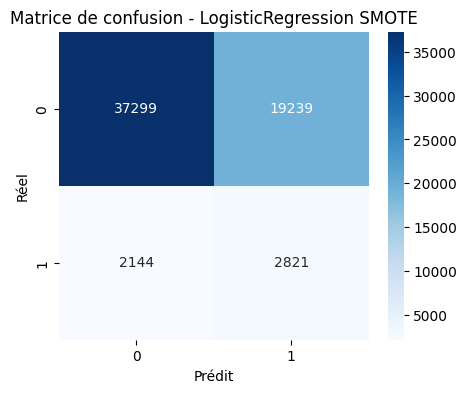

Résultats - LogisticRegression + SMOTE
accuracy: 0.6523
roc_auc: 0.6517
precision: 0.1279
recall: 0.5682
f1: 0.2088
business_cost: 40679.0000


In [15]:
with mlflow.start_run(run_name="logistic_regression_smote"):
    mlflow.set_tag("stage", "modeling")
    mlflow.set_tag("evaluation_type", "train_test")
    mlflow.set_tag("model_name", "LogisticRegression")
    mlflow.set_tag("model_family", "linear")
    mlflow.set_tag("imbalance_strategy", "SMOTE")
    mlflow.set_tag("threshold", "0.50")
    mlflow.set_tag("description", "Régression logistique entraînée après rééquilibrage SMOTE")

    # Régression logistique entraînée sur les données rééquilibrées
    log_reg_smote = LogisticRegression(
        max_iter=2000,
        random_state=42
    )

    log_reg_smote.fit(X_train_smote, y_train_smote)

    # Logging des paramètres
    mlflow.log_params({
        "model_type": "LogisticRegression_SMOTE",
        "max_iter": 2000
    })

    # Évaluation sur le jeu de test original (avec affichage et log MLflow)
    metrics, y_pred, y_proba = evaluate_model_and_log(log_reg_smote, X_test, y_test, "LogisticRegression SMOTE")

    # Affichage console
    print_metrics("LogisticRegression + SMOTE", metrics)

    # Stockage des résultats
    results.append({
        "model": "LogisticRegression_SMOTE",
        **metrics
    })

#### LightGBM + SMOTE

LightGBM gère déjà relativement bien les déséquilibres, mais un apprentissage sur un jeu rééquilibré peut parfois améliorer le rappel de la classe minoritaire.

[LightGBM] [Info] Number of positive: 226148, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.376768 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 43034
[LightGBM] [Info] Number of data points in the train set: 452296, number of used features: 297
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


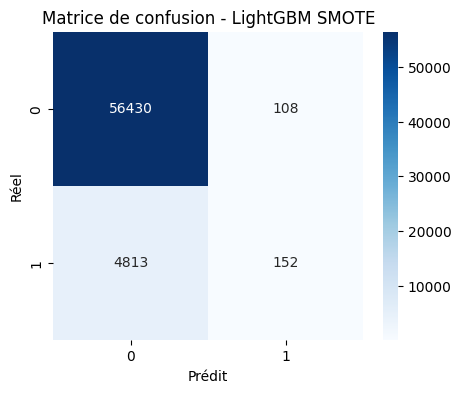

Résultats - LightGBM + SMOTE
accuracy: 0.9200
roc_auc: 0.7775
precision: 0.5846
recall: 0.0306
f1: 0.0582
business_cost: 48238.0000


In [16]:
with mlflow.start_run(run_name="lightgbm_smote"):
    mlflow.set_tag("stage", "modeling")
    mlflow.set_tag("evaluation_type", "train_test")
    mlflow.set_tag("model_name", "LightGBM")
    mlflow.set_tag("model_family", "boosting")
    mlflow.set_tag("imbalance_strategy", "SMOTE")
    mlflow.set_tag("threshold", "0.50")
    mlflow.set_tag("description", "LightGBM entraîné après rééquilibrage SMOTE")

    # LightGBM entraîné sur les données rééquilibrées
    lgbm_smote = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42
    )

    lgbm_smote.fit(X_train_smote, y_train_smote)

    # Logging des paramètres
    mlflow.log_params({
        "model_type": "LightGBM_SMOTE",
        "n_estimators": 300,
        "learning_rate": 0.05
    })

    # Évaluation sur le jeu de test original (avec affichage et log MLflow)
    metrics, y_pred, y_proba = evaluate_model_and_log(lgbm_smote, X_test, y_test, "LightGBM SMOTE")

    # Affichage console
    print_metrics("LightGBM + SMOTE", metrics)

    # Stockage des résultats
    results.append({
        "model": "LightGBM_SMOTE",
        **metrics
    })

#### XGBoost + SMOTE

XGBoost est un autre modèle de boosting très performant. Il est utile de vérifier si le rééquilibrage des classes améliore son compromis entre rappel et coût métier.

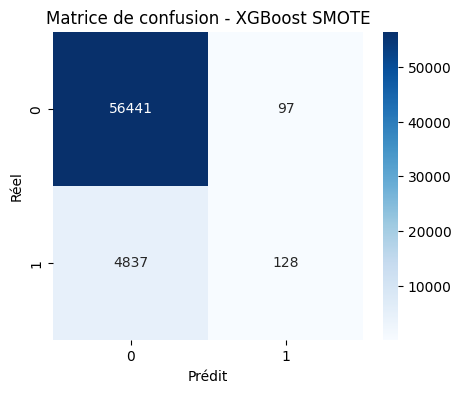

Résultats - XGBoost + SMOTE
accuracy: 0.9198
roc_auc: 0.7691
precision: 0.5689
recall: 0.0258
f1: 0.0493
business_cost: 48467.0000


In [17]:
with mlflow.start_run(run_name="xgboost_smote"):
    mlflow.set_tag("stage", "modeling")
    mlflow.set_tag("evaluation_type", "train_test")
    mlflow.set_tag("model_name", "XGBoost")
    mlflow.set_tag("model_family", "boosting")
    mlflow.set_tag("imbalance_strategy", "SMOTE")
    mlflow.set_tag("threshold", "0.50")
    mlflow.set_tag("description", "XGBoost entraîné après rééquilibrage SMOTE")

    # XGBoost entraîné sur les données rééquilibrées
    xgb_smote = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )

    xgb_smote.fit(X_train_smote, y_train_smote)

    # Logging des paramètres
    mlflow.log_params({
        "model_type": "XGBoost_SMOTE",
        "n_estimators": 300,
        "max_depth": 6
    })

    # Évaluation sur le jeu de test original (avec affichage et log MLflow)
    metrics, y_pred, y_proba = evaluate_model_and_log(xgb_smote, X_test, y_test, "XGBoost SMOTE")

    # Affichage console
    print_metrics("XGBoost + SMOTE", metrics)

    # Stockage des résultats
    results.append({
        "model": "XGBoost_SMOTE",
        **metrics
    })

#### Comparaison des modèles avec et sans rééquilibrage

In [18]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="business_cost",
    ascending=True
).reset_index(drop=True)

results_df.round(4)

,model,accuracy,roc_auc,precision,recall,f1,business_cost
0,LightGBM,0.7341,0.7804,0.1860,0.6796,0.2921,30671
1,XGBoost,0.7471,0.7775,0.1901,0.6542,0.2946,31009
2,LogisticRegression,0.6692,0.6567,0.1304,0.5466,0.2106,40605
3,LogisticRegression_SMOTE,0.6523,0.6517,0.1279,0.5682,0.2088,40679
4,LightGBM_SMOTE,0.9200,0.7775,0.5846,0.0306,0.0582,48238
5,XGBoost_SMOTE,0.9198,0.7691,0.5689,0.0258,0.0493,48467
6,RandomForest,0.9192,0.7481,0.4286,0.0012,0.0024,49598
7,DummyClassifier,0.9193,0.5000,0.0000,0.0000,0.0000,49650


Le sur-échantillonnage SMOTE n’apporte pas d’amélioration sur les modèles testés.

Les modèles de boosting (LightGBM et XGBoost) obtiennent des résultats nettement meilleurs sans SMOTE, ce qui suggère que la pondération des classes ou leur robustesse naturelle au déséquilibre suffit dans ce contexte.

SMOTE ne sera donc pas retenu pour la suite de l’étude.

### Validation croisée

Afin d’obtenir une estimation plus robuste des performances, les modèles sont maintenant comparés via validation croisée stratifiée à 5 folds.

In [19]:
# Scorer coût métier pour cross-validation (inversion du signe car sklearn maximise les scores)
def business_cost_cv(y_true, y_pred):
    return business_cost(y_true, y_pred)

cost_scorer = make_scorer(
    business_cost_cv,
    greater_is_better=False
)

In [20]:
# Métriques utilisées en validation croisée
scoring = {
    "roc_auc": "roc_auc",
    "recall": "recall",
    "f1": "f1",
    "accuracy": "accuracy",
    "business_cost": cost_scorer
}

In [21]:
# Validation croisée stratifiée
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [22]:
# Modèles testés
models = {
    "DummyClassifier": DummyClassifier(strategy="most_frequent"),

    "LogisticRegression": LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        class_weight="balanced",
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
}

In [23]:
# Cross-validation sur tous les modèles
cv_results = []

for name, model in models.items():

    with mlflow.start_run(run_name=f"{name}_cross_validation"):

        # Tags standardisés
        mlflow.set_tag("stage", "modeling")
        mlflow.set_tag("evaluation_type", "cross_validation")
        mlflow.set_tag("model_name", name)
        mlflow.set_tag("model_family", model_families[name])
        mlflow.set_tag("imbalance_strategy", imbalance_strategies[name])
        mlflow.set_tag("validation", "StratifiedKFold_5")
        mlflow.set_tag("threshold", "0.50")
        mlflow.set_tag("description", "Performance moyenne en validation croisée stratifiée")

        # Validation croisée stratifiée sur 5 folds
        scores = cross_validate(
            estimator=model,
            X=X_train,
            y=y_train,
            cv=cv,
            scoring=scoring,
            n_jobs=-1
        )

        # Moyenne des performances obtenues sur les folds
        row = {
            "model": name,
            "roc_auc_mean": scores["test_roc_auc"].mean(),
            "recall_mean": scores["test_recall"].mean(),
            "f1_mean": scores["test_f1"].mean(),
            "accuracy_mean": scores["test_accuracy"].mean(),
            "business_cost_mean": -scores["test_business_cost"].mean()
        }

        # Enregistrement des résultats dans MLflow
        mlflow.log_metrics({
            "accuracy": row["accuracy_mean"],
            "roc_auc": row["roc_auc_mean"],
            "recall": row["recall_mean"],
            "f1": row["f1_mean"],
            "business_cost": row["business_cost_mean"]
        })

        cv_results.append(row)

In [24]:
# Tableau final
cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="business_cost_mean",
    ascending=True
).reset_index(drop=True)

cv_results_df.round(4)

,model,roc_auc_mean,recall_mean,f1_mean,accuracy_mean,business_cost_mean
0,LightGBM,0.7751,0.6692,0.2902,0.7357,24829.2
1,LogisticRegression,0.6550,0.5554,0.2104,0.6634,32454.2
2,XGBoost,0.7762,0.0369,0.0691,0.9198,38376.0
3,RandomForest,0.7412,0.0015,0.0029,0.9192,39669.0
4,DummyClassifier,0.5000,0.0000,0.0000,0.9193,39720.0


- Modèle retenu : Le LightGBM est le meilleur modèle. C'est celui qui minimise le coût métier (24 829) et qui maintient le meilleur Recall (0.6692).

- Alerte sur le XGBoost : Son Recall s'effondre en validation croisée (0.0369). Cela montre qu'il n'est pas robuste et qu'il faisait de l'overfitting lors des tests précédents.

- Piège de l'Accuracy : Le Random Forest et le DummyClassifier ont une excellente Accuracy (92%) mais un Recall nul. Ils ne détectent aucun client à risque, ce qui engendre un coût financier maximal.

- Conclusion : On privilégie le LightGBM car il offre le meilleur compromis entre la détection des risques et la stabilité des performances sur l'ensemble du jeu de données.

### Enregistrement du champion 


Critères d'élection :
- Filtre de sécurité : ROC-AUC moyen > 0.70
- Performance métier : business_cost moyen le plus faible possible

In [25]:
try:
    # Filtrage des modèles jugés suffisamment fiables
    eligible_models = cv_results_df[
        cv_results_df["roc_auc_mean"] > 0.70
    ].copy()

    # Vérification qu'au moins un modèle respecte le seuil minimal
    if eligible_models.empty:
        raise ValueError("Aucun modèle ne respecte le seuil ROC-AUC > 0.70")

    # Sélection du meilleur modèle selon le coût métier
    champion_row = eligible_models.sort_values(
        by="business_cost_mean",
        ascending=True
    ).iloc[0]

    champion_name = champion_row["model"]

    print(f"Modèle champion détecté : {champion_name}")
    print(f"ROC-AUC moyen : {champion_row['roc_auc_mean']:.4f}")
    print(f"Recall moyen  : {champion_row['recall_mean']:.4f}")
    print(f"Coût moyen    : {champion_row['business_cost_mean']:.0f}")

    # Association nom du modèle -> objet déjà entraîné sur tout X_train
    model_objects = {
        "DummyClassifier": dummy,
        "LogisticRegression": log_reg,
        "RandomForest": rf,
        "LightGBM": lgbm,
        "XGBoost": xgb
    }

    final_model = model_objects[champion_name]

    # Dossier local optionnel pour exports modèles
    models_dir = PROJECT_ROOT / "models"
    models_dir.mkdir(exist_ok=True)

    # Run MLflow dédié à l'enregistrement du modèle champion
    with mlflow.start_run(run_name="FINAL_CHAMPION_REGISTRATION"):

        # Tags standardisés pour faciliter la lecture dans MLflow
        mlflow.set_tag("stage", "model_registry")
        mlflow.set_tag("evaluation_type", "cross_validation")
        mlflow.set_tag("model_name", champion_name)
        mlflow.set_tag("model_family", model_families[champion_name])
        mlflow.set_tag("imbalance_strategy", imbalance_strategies[champion_name])
        mlflow.set_tag("selection_type", "automated_cv_selection")
        mlflow.set_tag("selection_metric", "business_cost")
        mlflow.set_tag("validation", "StratifiedKFold_5")
        mlflow.set_tag("threshold", "0.50")
        mlflow.set_tag("description", "Enregistrement du meilleur modèle issu de la validation croisée")

        # Métriques standardisées pour rester comparables avec les autres runs MLflow
        mlflow.log_metrics({
            "accuracy": champion_row["accuracy_mean"],
            "roc_auc": champion_row["roc_auc_mean"],
            "recall": champion_row["recall_mean"],
            "f1": champion_row["f1_mean"],
            "business_cost": champion_row["business_cost_mean"]
        })

        # Paramètre de traçabilité
        mlflow.log_param("selected_model_name", champion_name)

        # Enregistrement dans MLflow Model Registry
        if champion_name == "LightGBM":
            mlflow.lightgbm.log_model(
                final_model,
                artifact_path="model",
                registered_model_name="Credit_Scoring_Champion"
            )

        elif champion_name == "XGBoost":
            mlflow.xgboost.log_model(
                final_model,
                artifact_path="model",
                registered_model_name="Credit_Scoring_Champion"
            )

        else:
            mlflow.sklearn.log_model(
                final_model,
                artifact_path="model",
                registered_model_name="Credit_Scoring_Champion"
            )

    print(f"{champion_name} enregistré comme champion dans MLflow.")

except Exception as e:
    print(f"Erreur lors de l'enregistrement du champion : {e}")

2026/04/25 04:40:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Modèle champion détecté : LightGBM
ROC-AUC moyen : 0.7751
Recall moyen  : 0.6692
Coût moyen    : 24829


2026/04/25 04:40:26 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LightGBM enregistré comme champion dans MLflow.


Successfully registered model 'Credit_Scoring_Champion'.
Created version '1' of model 'Credit_Scoring_Champion'.
